In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned/football_matches_cleaned.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.head()

,match_id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,country_name,home_team_name,home_team_short_name,away_team_name,away_team_short_name,result,goal_diff,total_goals,home_points,away_points
0,1,1,1,2008/2009,1,2008-08-17,492473,9987,9993,1,...,Belgium,KRC Genk,GEN,Beerschot AC,BAC,Draw,0,2,1,1
1,2,1,1,2008/2009,1,2008-08-16,492474,10000,9994,0,...,Belgium,SV Zulte-Waregem,ZUL,Sporting Lokeren,LOK,Draw,0,0,1,1
2,3,1,1,2008/2009,1,2008-08-16,492475,9984,8635,0,...,Belgium,KSV Cercle Brugge,CEB,RSC Anderlecht,AND,Away Win,-3,3,0,3
3,4,1,1,2008/2009,1,2008-08-17,492476,9991,9998,5,...,Belgium,KAA Gent,GEN,RAEC Mons,MON,Home Win,5,5,3,0
4,5,1,1,2008/2009,1,2008-08-16,492477,7947,9985,1,...,Belgium,FCV Dender EH,DEN,Standard de Liège,STL,Away Win,-2,4,0,3


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (25979, 22)

Columns:
 ['match_id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'league_name', 'country_name', 'home_team_name', 'home_team_short_name', 'away_team_name', 'away_team_short_name', 'result', 'goal_diff', 'total_goals', 'home_points', 'away_points']

Missing values:
 match_id                0
country_id              0
league_id               0
season                  0
stage                   0
date                    0
match_api_id            0
home_team_api_id        0
away_team_api_id        0
home_team_goal          0
away_team_goal          0
league_name             0
country_name            0
home_team_name          0
home_team_short_name    0
away_team_name          0
away_team_short_name    0
result                  0
goal_diff               0
total_goals             0
home_points             0
away_points             0
dtype: int64

Data types:
 match_id   

# Dataset Overview

This dataset contains football match records with team names, league names, match outcomes, goals scored, and derived features such as goal difference and total goals.

The main focus of this analysis is:
- match results
- home advantage
- team performance
- league scoring trends
- season-level patterns

In [4]:
# Create a team-level table by combining home and away match records
home = df[[
    "season", "date", "league_name", "country_name",
    "home_team_name", "away_team_name",
    "home_team_goal", "away_team_goal", "result"
]].copy()

home = home.rename(columns={
    "home_team_name": "team",
    "away_team_name": "opponent",
    "home_team_goal": "goals_for",
    "away_team_goal": "goals_against"
})

home["side"] = "Home"
home["points"] = np.where(home["result"] == "Home Win", 3,
                 np.where(home["result"] == "Draw", 1, 0))

away = df[[
    "season", "date", "league_name", "country_name",
    "home_team_name", "away_team_name",
    "home_team_goal", "away_team_goal", "result"
]].copy()

away = away.rename(columns={
    "away_team_name": "team",
    "home_team_name": "opponent",
    "away_team_goal": "goals_for",
    "home_team_goal": "goals_against"
})

away["side"] = "Away"
away["points"] = np.where(away["result"] == "Away Win", 3,
                 np.where(away["result"] == "Draw", 1, 0))

team_matches = pd.concat([home, away], ignore_index=True)

team_matches["win"] = (team_matches["points"] == 3).astype(int)
team_matches["draw"] = (team_matches["points"] == 1).astype(int)
team_matches["loss"] = (team_matches["points"] == 0).astype(int)

team_matches.head()

,season,date,league_name,country_name,team,opponent,goals_for,goals_against,result,side,points,win,draw,loss
0,2008/2009,2008-08-17,Belgium Jupiler League,Belgium,KRC Genk,Beerschot AC,1,1,Draw,Home,1,0,1,0
1,2008/2009,2008-08-16,Belgium Jupiler League,Belgium,SV Zulte-Waregem,Sporting Lokeren,0,0,Draw,Home,1,0,1,0
2,2008/2009,2008-08-16,Belgium Jupiler League,Belgium,KSV Cercle Brugge,RSC Anderlecht,0,3,Away Win,Home,0,0,0,1
3,2008/2009,2008-08-17,Belgium Jupiler League,Belgium,KAA Gent,RAEC Mons,5,0,Home Win,Home,3,1,0,0
4,2008/2009,2008-08-16,Belgium Jupiler League,Belgium,FCV Dender EH,Standard de Liège,1,3,Away Win,Home,0,0,0,1


result
Home Win    11917
Away Win     7466
Draw         6596
Name: count, dtype: int64


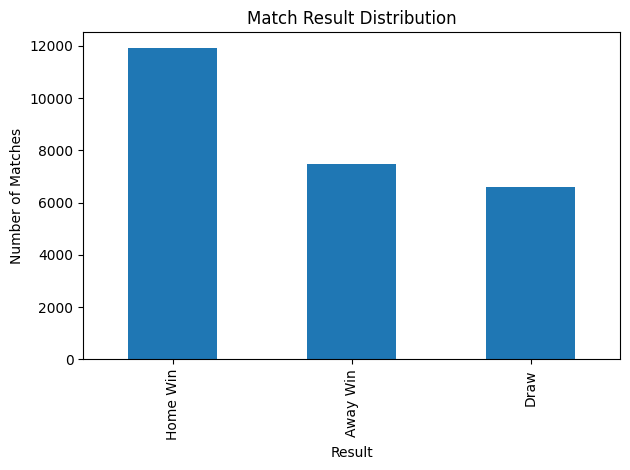

In [34]:
#overall match result distribution
result_counts = df["result"].value_counts()
print(result_counts)

ax = result_counts.plot(kind="bar")
ax.set_title("Match Result Distribution")
ax.set_xlabel("Result")
ax.set_ylabel("Number of Matches")
plt.tight_layout()
plt.savefig("../outputs/charts/Match Result Distribution.png", bbox_inches="tight")
plt.show()

# Insight
Home wins are usually the most common result, followed by away wins and draws.

# Business meaning
This suggests home advantage may be an important factor in football performance.

# Recommendation
Analyze team performance separately for home and away matches.

In [7]:
#overall goals analysis
print("Average goals per match:", round(df["total_goals"].mean(), 2))
print("Average home goals:", round(df["home_team_goal"].mean(), 2))
print("Average away goals:", round(df["away_team_goal"].mean(), 2))

Average goals per match: 2.71
Average home goals: 1.54
Average away goals: 1.16


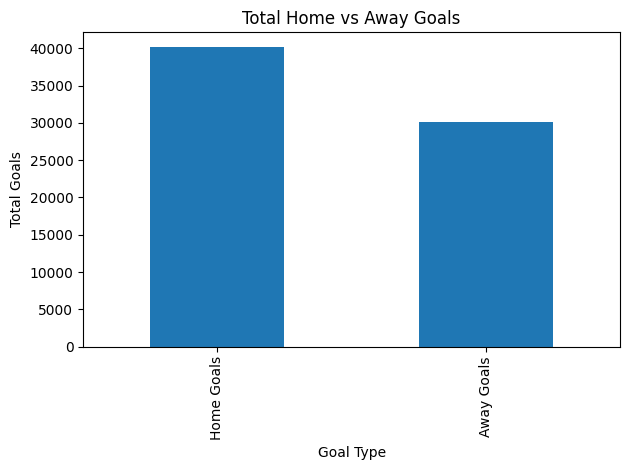

In [33]:
goals_summary = pd.Series({
    "Home Goals": df["home_team_goal"].sum(),
    "Away Goals": df["away_team_goal"].sum()
})

ax = goals_summary.plot(kind="bar")
ax.set_title("Total Home vs Away Goals")
ax.set_xlabel("Goal Type")
ax.set_ylabel("Total Goals")
plt.tight_layout()
plt.savefig("../outputs/charts/Total Home vs Away Goals.png", bbox_inches="tight")
plt.show()

# Insight
Home teams generally score slightly more goals than away teams.

# Business meaning
Home field advantage may influence attacking performance.

# Recommendation
Compare team scoring patterns at home and away to find stronger tactical trends.

result
Home Win    45.87
Away Win    28.74
Draw        25.39
Name: proportion, dtype: float64


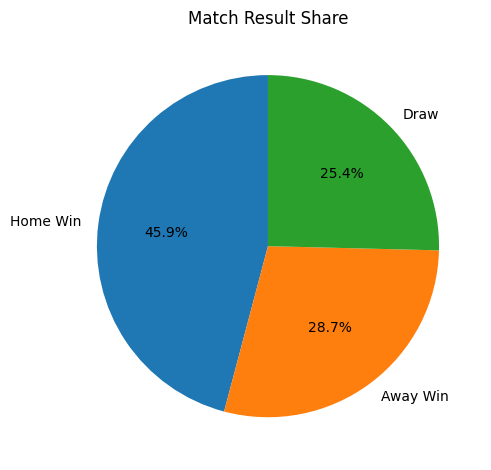

In [32]:
#home win, away win, draw percentages
result_pct = df["result"].value_counts(normalize=True) * 100
print(result_pct.round(2))

ax = result_pct.plot(kind="pie", autopct="%1.1f%%", startangle=90)
ax.set_ylabel("")
ax.set_title("Match Result Share")
plt.tight_layout()
plt.savefig("../outputs/charts/Match Result Share.png", bbox_inches="tight")
plt.show()

# Insight
A large share of matches end in home wins or draws.

# Business meaning
Match outcome is influenced by venue and competitive balance.

# Recommendation
Use home/away status as an important feature in prediction or performance analysis.

season
2008/2009    2.607336
2009/2010    2.672446
2010/2011    2.683742
2011/2012    2.716460
2012/2013    2.772699
2013/2014    2.766821
2014/2015    2.675789
2015/2016    2.754660
Name: total_goals, dtype: float64


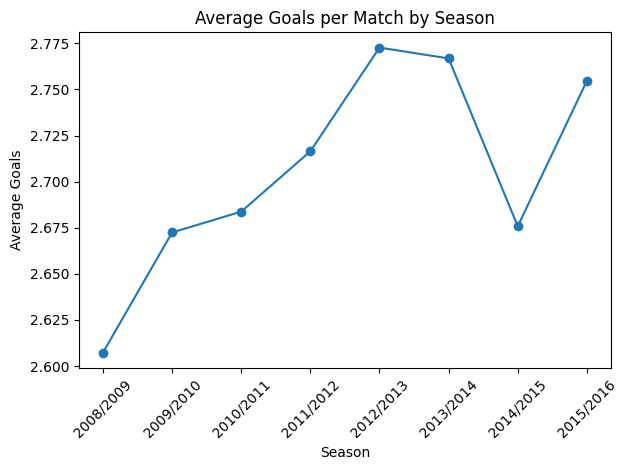

In [31]:
#goals by season
season_goals = df.groupby("season")["total_goals"].mean().sort_index()
print(season_goals)

ax = season_goals.plot(kind="line", marker="o")
ax.set_title("Average Goals per Match by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/Average Goals per Match by Season.png", bbox_inches="tight")
plt.show()

# Insight
Some seasons are more high-scoring than others.

# Business meaning
Scoring trends can change over time due to tactics, rules, or player quality.

# Recommendation
Compare season trends before making long-term performance claims.

league_name
Netherlands Eredivisie      3.080882
Switzerland Super League    2.929677
Germany 1. Bundesliga       2.901552
Belgium Jupiler League      2.801505
Spain LIGA BBVA             2.767105
England Premier League      2.710526
Scotland Premier League     2.633772
Italy Serie A               2.616838
Portugal Liga ZON Sagres    2.534600
France Ligue 1              2.443092
Poland Ekstraklasa          2.425000
Name: total_goals, dtype: float64


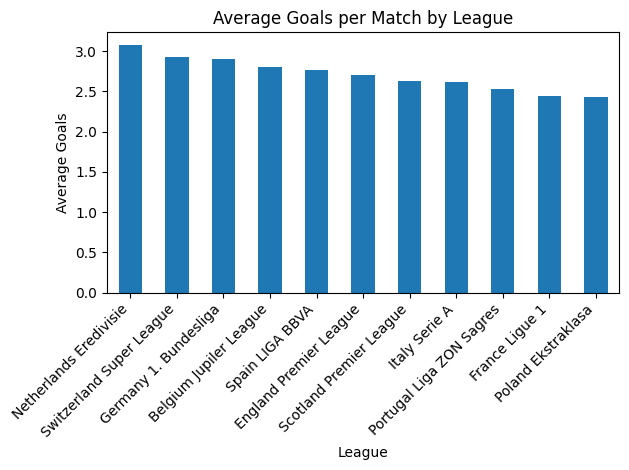

In [30]:
#League-level scoring analysis
league_goals = (
    df.groupby("league_name")["total_goals"]
    .mean()
    .sort_values(ascending=False)
)

print(league_goals)

ax = league_goals.plot(kind="bar")
ax.set_title("Average Goals per Match by League")
ax.set_xlabel("League")
ax.set_ylabel("Average Goals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/charts/Average Goals per Match by League.png", bbox_inches="tight")
plt.show()

# Insight
Some leagues are more goal-heavy than others.

# Business meaning
League style affects match tempo and scoring patterns.

# Recommendation
Use league-level segmentation when comparing team performance.

In [ ]:
#Top teams by average points per match
team_summary = (
    team_matches.groupby("team")
    .agg(
        matches=("team", "size"),
        wins=("win", "sum"),
        draws=("draw", "sum"),
        losses=("loss", "sum"),
        total_points=("points", "sum"),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum")
    )
    .reset_index()
)

team_summary["points_per_match"] = team_summary["total_points"] / team_summary["matches"]
team_summary["win_rate"] = team_summary["wins"] / team_summary["matches"] * 100
team_summary["goal_diff"] = team_summary["goals_for"] - team_summary["goals_against"]

team_summary.sort_values("points_per_match", ascending=False).head(10)

,team,matches,wins,draws,losses,total_points,goals_for,goals_against,points_per_match,win_rate,goal_diff
75,FC Barcelona,304,234,43,27,745,849,232,2.450658,76.973684,617
232,SL Benfica,248,185,36,27,591,568,186,2.383065,74.596774,382
89,FC Porto,248,183,42,23,591,541,161,2.383065,73.790323,380
211,Real Madrid CF,304,228,36,40,720,843,304,2.368421,75.000000,539
49,Celtic,304,218,50,36,704,695,223,2.315789,71.710526,472
207,Rangers,152,108,25,19,349,324,113,2.296053,71.052632,211
77,FC Bayern Munich,272,193,44,35,623,653,211,2.290441,70.955882,442
15,Ajax,272,181,59,32,602,647,236,2.213235,66.544118,411
205,RSC Anderlecht,212,136,49,27,457,427,182,2.155660,64.150943,245
184,PSV,272,178,47,47,581,652,294,2.136029,65.441176,358


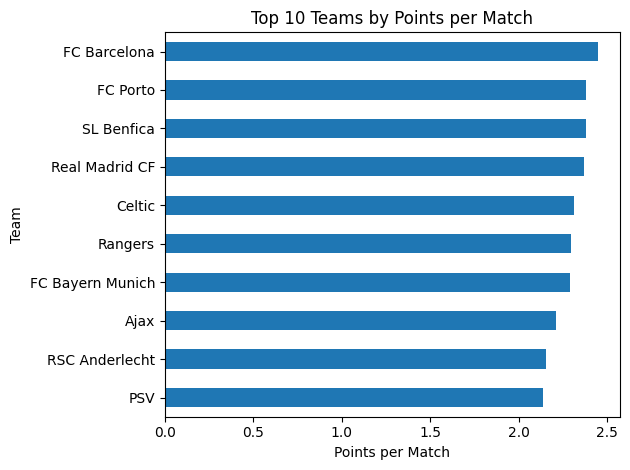

In [29]:
top_teams = team_summary.sort_values("points_per_match", ascending=False).head(10)

ax = top_teams.sort_values("points_per_match").plot(
    kind="barh",
    x="team",
    y="points_per_match",
    legend=False
)
ax.set_title("Top 10 Teams by Points per Match")
ax.set_xlabel("Points per Match")
ax.set_ylabel("Team")
plt.tight_layout()
plt.savefig("../outputs/charts/Top 10 Teams by Points per Match.png", bbox_inches="tight")
plt.show()

# Insight
The strongest teams consistently earn more points per match.

# Business meaning
Points per match is a better performance indicator than raw wins alone.

# Recommendation
Use points per match and goal difference together to evaluate team quality.

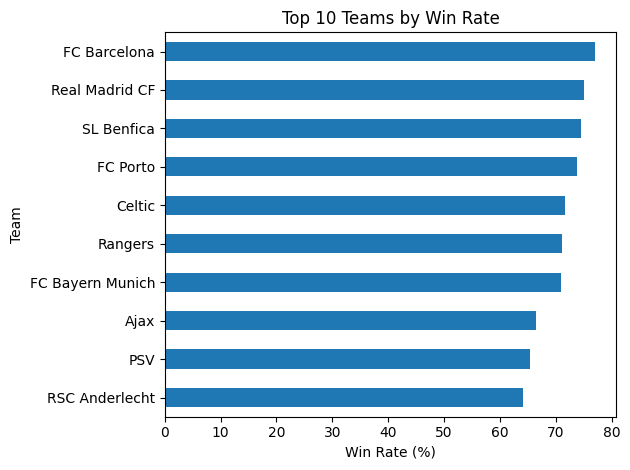

In [28]:
#Top teams by win rate
top_win_teams = team_summary.sort_values("win_rate", ascending=False).head(10)

ax = top_win_teams.sort_values("win_rate").plot(
    kind="barh",
    x="team",
    y="win_rate",
    legend=False
)
ax.set_title("Top 10 Teams by Win Rate")
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Team")
plt.tight_layout()
plt.savefig("../outputs/charts/Top 10 Teams by Win Rate.png", bbox_inches="tight")
plt.show()

# Insight
Some teams win far more often than others.

# Business meaning
Win rate reflects consistency, not just occasional strong matches.

# Recommendation
Compare win rate with points per match and goal difference for a fuller performance view.

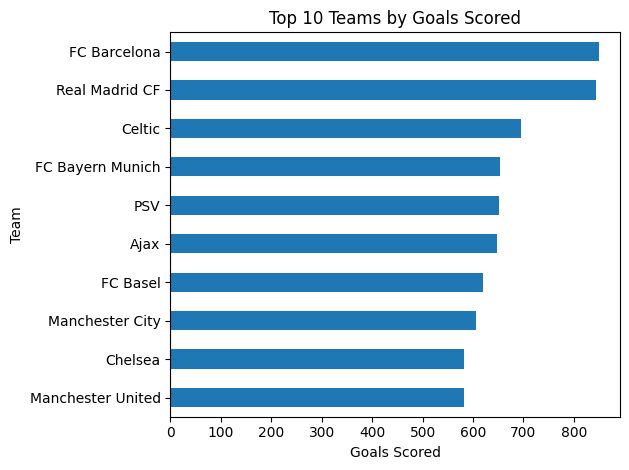

In [27]:
top_attack = team_summary.sort_values("goals_for", ascending=False).head(10)

ax = top_attack.sort_values("goals_for").plot(
    kind="barh",
    x="team",
    y="goals_for",
    legend=False
)
ax.set_title("Top 10 Teams by Goals Scored")
ax.set_xlabel("Goals Scored")
ax.set_ylabel("Team")
plt.tight_layout()
plt.savefig("../outputs/charts/Top 10 Teams by Goals Scored.png", bbox_inches="tight")
plt.show()

# Insight
A few teams dominate in total goals scored.

# Business meaning
Strong attacking teams may create more exciting or dominant performances.

# Recommendation
Compare attacking strength with defensive weakness before drawing conclusions.

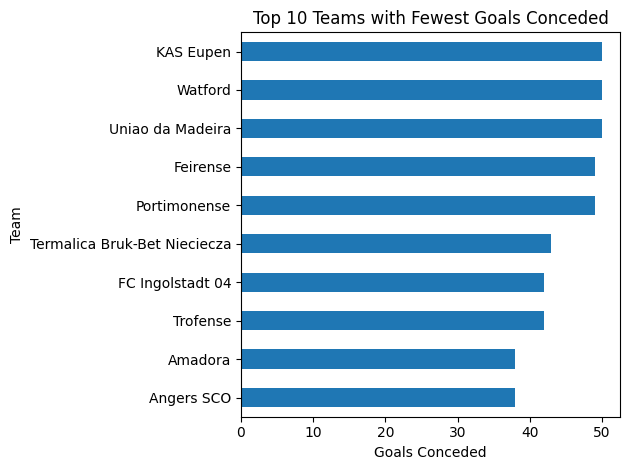

In [26]:
#Best defensive teams
best_defense = team_summary.groupby("team")["goals_against"].sum().sort_values().head(10)

ax = best_defense.sort_values().plot(kind="barh")
ax.set_title("Top 10 Teams with Fewest Goals Conceded")
ax.set_xlabel("Goals Conceded")
ax.set_ylabel("Team")
plt.tight_layout()
plt.savefig("../outputs/charts/top team with fewest goals conceded.png", bbox_inches="tight")
plt.show()

# Insight
Some teams are strong because they concede very few goals.

# Business meaning
Defense is just as important as scoring in overall performance.

# Recommendation
Highlight teams with both high scoring and low concessions as the best overall performers.

In [17]:
#home vs away performance
home_away_summary = team_matches.groupby("side").agg(
    matches=("side", "size"),
    avg_goals_for=("goals_for", "mean"),
    avg_goals_against=("goals_against", "mean"),
    avg_points=("points", "mean")
)

home_away_summary

,matches,avg_goals_for,avg_goals_against,avg_points
side,,,,
Away,25979,1.160938,1.544594,1.116055
Home,25979,1.544594,1.160938,1.630047


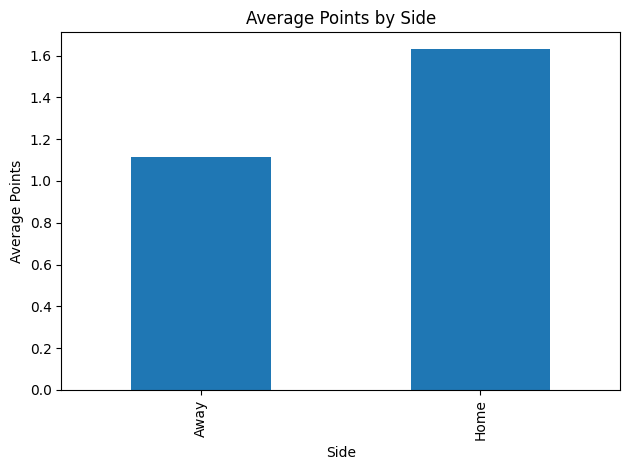

In [25]:
ax = home_away_summary["avg_points"].plot(kind="bar")
ax.set_title("Average Points by Side")
ax.set_xlabel("Side")
ax.set_ylabel("Average Points")
plt.tight_layout()
plt.savefig("../outputs/charts/average points by side.png", bbox_inches="tight")
plt.show()

# Insight
Teams often perform differently at home and away.

# Business meaning
Venue has a measurable effect on football performance.

# Recommendation
Include home and away splits in any team evaluation or prediction model.

In [19]:
#Season-level team performance
season_team = (
    team_matches.groupby(["season", "team"])
    .agg(
        matches=("team", "size"),
        points=("points", "sum"),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum")
    )
    .reset_index()
)

season_team["points_per_match"] = season_team["points"] / season_team["matches"]
season_team.head()

,season,team,matches,points,goals_for,goals_against,points_per_match
0,2008/2009,1. FC Köln,34,39,35,50,1.147059
1,2008/2009,AC Bellinzona,36,43,44,51,1.194444
2,2008/2009,ADO Den Haag,34,32,41,58,0.941176
3,2008/2009,AJ Auxerre,38,55,35,35,1.447368
4,2008/2009,AS Monaco,38,45,41,45,1.184211


In [20]:
top_each_season = (
    season_team.sort_values(["season", "points_per_match"], ascending=[True, False])
    .groupby("season")
    .head(1)
)

top_each_season[["season", "team", "points_per_match"]]

,season,team,points_per_match
105,2008/2009,Manchester United,2.368421
233,2009/2010,FC Barcelona,2.605263
427,2010/2011,FC Porto,2.800000
689,2011/2012,Real Madrid CF,2.631579
781,2012/2013,FC Bayern Munich,2.676471
1009,2013/2014,Juventus,2.684211
1220,2014/2015,PSV,2.588235
1336,2015/2016,FC Bayern Munich,2.588235


# Insight
The best-performing team can change from season to season.

# Business meaning
Football performance is dynamic and depends on squads, tactics, and competition.

# Recommendation
Use season-by-season comparisons instead of one overall ranking only.

In [21]:
#final summary table
summary = {
    "matches": len(df),
    "avg_total_goals": round(df["total_goals"].mean(), 2),
    "home_win_rate": round((df["result"] == "Home Win").mean() * 100, 2),
    "away_win_rate": round((df["result"] == "Away Win").mean() * 100, 2),
    "draw_rate": round((df["result"] == "Draw").mean() * 100, 2)
}

summary

{'matches': 25979,
 'avg_total_goals': np.float64(2.71),
 'home_win_rate': np.float64(45.87),
 'away_win_rate': np.float64(28.74),
 'draw_rate': np.float64(25.39)}

# EDA Summary

This analysis shows that home advantage, goal trends, season patterns, and team consistency are the most useful areas for understanding football performance.

The next step is to move this into SQL analysis and then Power BI visualization.

In [22]:
plt.savefig("../outputs/charts/chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>